In [12]:

import torch 
from matplotlib import pyplot as plt
import numpy as np
from GaNN.models.GaNN import GaNN
from GaNN.synth import generate
from GaNN.synth import utils 
from GaNN.train.train import train

from hypnettorch.mnets import MLP
from hypnettorch.hnets import HMLP


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


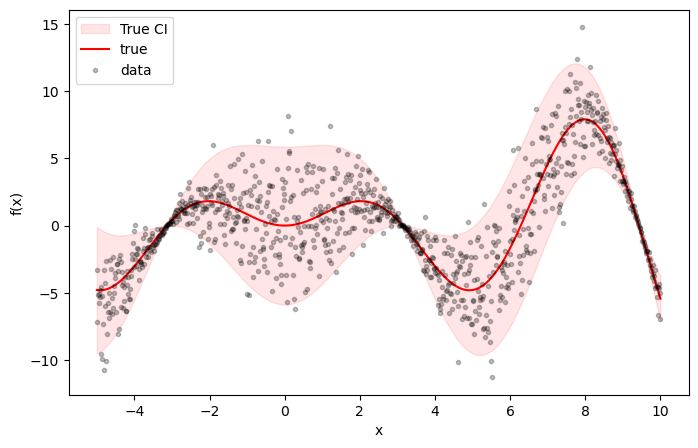

In [51]:
x,y,y_true,true_lcb,true_ucb = generate.simple1d(N=1000, scale=3)

utils.plot1d(x,y,y_true,true_lcb,true_ucb)

In [52]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

mlp = MLP(n_in=1, n_out=1, hidden_layers=[50,50],
                  no_weights=True).to(device)

hnet = HMLP(mlp.param_shapes, uncond_in_size=0, cond_in_size=8,
            layers=[50], num_cond_embs=2).to(device)

hnet.apply_hyperfan_init(mnet=mlp)


Creating an MLP with 2701 weights.
Created MLP Hypernet.
Hypernetwork with 138217 weights and 2701 outputs (compression ratio: 51.17).
The network consists of 138201 unconditional weights (138201 internally maintained) and 16 conditional weights (16 internally maintained).


In [54]:
lr=1e-4
batch_size=32
num_epochs=250

# Adam usually works well in combination with hypernetwork training.
optim = torch.optim.Adam(hnet.internal_params, lr=lr)
crit = torch.nn.MSELoss()
#crit = torch.nn.NLLLoss()

x = x.unsqueeze(-1).to(device)
y = y.unsqueeze(-1).to(device)

losses = []
for i in range(num_epochs): 

        batch_loss = []
        _losses = []
        for idx in torch.split(torch.randperm(x.size(0)), batch_size): 
            optim.zero_grad()
            W = hnet(cond_id=0)
            yhat = mlp(x[idx], W)
            loss = crit(yhat, y[idx])
            loss.backward()
            optim.step()
            _losses.append(loss.item())
        losses.append(np.mean(_losses))

        print(f'epoch: {i} --> loss: {losses[-1]}', end='\r')

In [55]:
model, losses = train(x.view(-1,1),y.view(-1,1), loss_fn='mse', model_kwargs={'hidden_channels':50, 
                                                               'layers':2, 
                                                               'gaussian_channels':8, 
                                                               'width':50},
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs, compile=False)

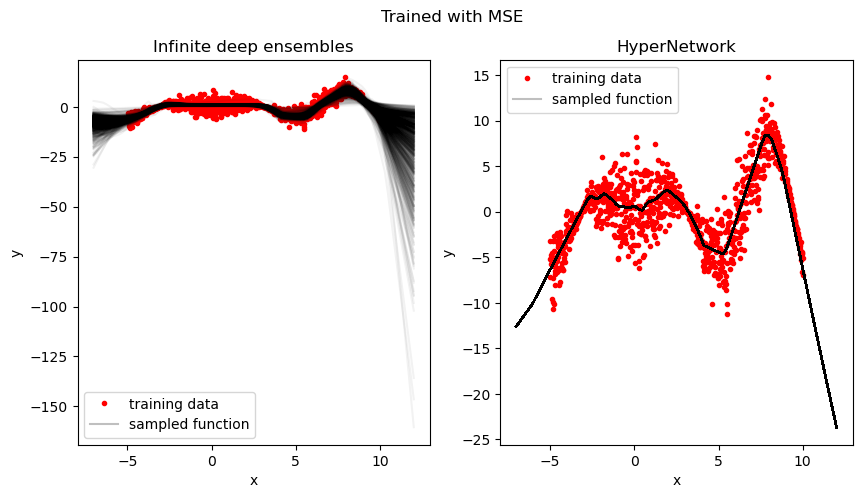

In [61]:

f, axes = plt.subplots(1,2,figsize=(10,5))

hnet = hnet.cpu()
mnet = mlp.cpu()
x_ = x.detach().squeeze().cpu().numpy()
y_ = y.detach().squeeze().cpu().numpy()

x2 = torch.linspace(-7,12,100)
yhat_ours = model(x2.unsqueeze(1), 1000)

axes[0].plot(x_,y_, 'r.', label='training data')
first=True
for yyhat in yhat_ours.detach().cpu().numpy(): 
    if first: 
        axes[0].plot(x2.squeeze().detach().cpu().numpy(), yyhat, 'k-', alpha=0.25, label='sampled function')
        first = False
    else: 
        axes[0].plot(x2.detach().cpu().numpy(), yyhat, 'k-', alpha=0.05)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()

axes[1].plot(x_,y_, 'r.', label='training data')
first=True
for i in range(1000): 
    W = hnet(cond_id=0)
    yyhat = mlp(x2.unsqueeze(1), W).detach().cpu().numpy()
    if first: 
        axes[1].plot(x2.squeeze().detach().cpu().numpy(), yyhat, 'k-', alpha=0.25, label='sampled function')
        first = False
    else: 
        axes[1].plot(x2.detach().cpu().numpy(), yyhat, 'k-', alpha=0.05)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()

axes[0].set_title('Infinite deep ensembles')
axes[1].set_title('HyperNetwork')

plt.suptitle('Trained with MSE')
plt.show()